# Task 2: Customer 360 Gold Table

Using the datasets provided, as well as the linkage table, design and implement a consolidated customer_360 table. The table should also include the following features (or as many as are feasible). Implement this in a Jupyter Notebook (or an equivalent platform).

| # | Feature | Source Tables |
|---|---------|-------------|
| 1 | Total ticket spend (lifetime) | `ticket_purchases` |
| 2 | Number of unique events attended | `event_attendance` |
| 3 | Average ticket value | `ticket_purchases` |
| 4 | Total merchandise / retail spend | `retail_transactions` |
| 5 | Number of retail purchases in the last 90 days | `retail_transactions` |
| 6 | Days since last brand interaction (any channel) | all activity tables |

### Approach
1. **Load & validate** all datasets
2. **Resolve identities** via the linkage table, with a fallback strategy for unlinked IDs
3. **Aggregate features** per `universal_id` from each source system
4. **Merge demographics** from the multi-system `customers` table
5. **Assemble** the final `customer_360` gold table
6. **Validate** output quality

## Setup & Data Loading

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta

In [22]:
# Use the latest date across all datasets as the reference point
REFERENCE_DATE = None

# Get the current directory
current_directory = os.getcwd()
path = os.path.join(current_directory, "datasets")
print(f"Fetching data from directory: {path}")

# ... TICKETMASTER ...
# `ticket_purchases`: Online ticket purchases per event
ticket_purchases = pd.read_csv(f"{path}/ticket_purchases.csv")
print(f"... `ticket_purchases.csv` loaded {ticket_purchases.shape}")

# `event_attendance`: Attendance scan-ins by customers
event_attendance = pd.read_csv(f"{path}/event_attendance.csv")
print(f"... `event_attendance.csv` loaded {event_attendance.shape}")

# `events`: Metadata for each event
events = pd.read_csv(f"{path}/events.csv")
print(f"... `events.csv` loaded {events.shape}")

# ... SALESFORCE CRM ...
# `crm_interactions`: Contact history and opportunity stages
crm_interactions = pd.read_csv(f"{path}/crm_interactions.csv")
print(f"... `crm_interactions.csv` loaded {crm_interactions.shape}")

# ... GOOGLE ANALYTICS ...
# `web_sessions`: Website sessions including source, duration, and engagement
web_sessions = pd.read_csv(f"{path}/web_sessions.csv")
print(f"... `web_sessions.csv` loaded {web_sessions.shape}")

# ... RETAIL POS ...
# `retail_txns`: In-venue or merchandise store purchases
retail_txns = pd.read_csv(f"{path}/retail_transactions.csv")
print(f"... `retail_transactions.csv` loaded {retail_txns.shape}")

# ... CUSTOMER PROFILES ...
# `customers`: Partial demographic and signup metadata across systems
customers = pd.read_csv(f"{path}/customers.csv")
print(f"... `customers.csv` loaded {customers.shape}")

# ... CUSTOMER LINKAGE ...
# `customer_linkage`: A mapping table linking system-specific customer IDs to a shared universal_id
customer_linkage = pd.read_csv(f"{path}/customer_linkage.csv")
print(f"... `customer_linkage.csv` loaded {customer_linkage.shape}")

Fetching data from directory: /Users/wildg/Desktop/compass-analytics-interview/datasets
... `ticket_purchases.csv` loaded (500, 4)
... `event_attendance.csv` loaded (600, 3)
... `events.csv` loaded (50, 3)
... `crm_interactions.csv` loaded (400, 4)
... `web_sessions.csv` loaded (1000, 5)
... `retail_transactions.csv` loaded (700, 5)
... `customers.csv` loaded (200, 5)
... `customer_linkage.csv` loaded (120, 5)


In [23]:
datasets = {
  "ticket_purchases": ticket_purchases,
  "event_attendance": event_attendance,
  "events": events,
  "crm_interactions": crm_interactions,
  "web_sessions": web_sessions,
  "retail_txns": retail_txns,
  "customers": customers,
  "customer_linkage": customer_linkage
}

for name, df in datasets.items():
  print(f"===== {name} =====")
  display(df.head(3))

===== ticket_purchases =====


,customer_id,event_id,purchase_date,ticket_amount
0,tmc_00d9e230,evt_314081a9,2024-11-25,60.85
1,tmc_00d9e230,evt_cdedfbf7,2023-03-07,204.03
2,tmc_01835e69,evt_0cb72b53,2024-11-30,42.68


===== event_attendance =====


,customer_id,event_id,scan_timestamp
0,tmc_053ec30f,evt_9091d14e,2024-07-02
1,tmc_f3f735d8,evt_66f17cf8,2022-11-22
2,tmc_10557f84,evt_1787d2ff,2024-08-30


===== events =====


...

,customer_id,transaction_date,location,amount,product_category
0,rtc_de27f658,2022-08-29,Stadium C,159.55,Drink
1,rtc_9d34707d,2024-09-07,Stadium A,41.45,Souvenir
2,rtc_5d2685eb,2023-05-12,Stadium C,18.00,Apparel


===== customers =====


,customer_id,signup_date,city,gender,age_group
0,tmc_b20cc720,2025-05-27,Toronto,Female,18-24
1,tmc_34457841,2024-11-09,Toronto,Female,55+
2,tmc_c1651ef7,2023-01-22,Vancouver,Other,55+


===== customer_linkage =====


,universal_id,tmc_id,sfc_id,gac_id,rtc_id
0,cust_0000,tmc_41637348,sfc_5c688db9,gac_5c165a23,rtc_e1ff560e
1,cust_0001,tmc_a458e1cc,sfc_11b3cfa3,NaN,rtc_5d2685eb
2,cust_0002,tmc_5fdfdc30,sfc_184cf634,gac_f820c17c,rtc_820d29e4


## Date Parsing

In [24]:
# Parse all date columns
date_map = {
  "ticket_purchases": "purchase_date",
  "event_attendance": "scan_timestamp",
  "events": "event_date",
  "crm_interactions": "contact_date",
  "web_sessions": "session_date",
  "retail_txns": "transaction_date",
  "customers": "signup_date",
}

for name, col in date_map.items():
  datasets[name][col] = pd.to_datetime(datasets[name][col], errors="coerce")

# Set reference date to the latest date across all activity tables
activity_tables = [
  "ticket_purchases", "event_attendance", "crm_interactions", 
  "web_sessions", "retail_txns"
]
max_dates = [datasets[t][date_map[t]].max() for t in activity_tables]
REFERENCE_DATE = max(max_dates).normalize()

print(f"Reference date (max across all sources): {REFERENCE_DATE.date()}")
print(f"90-day cutoff: {(REFERENCE_DATE - timedelta(days=90)).date()}")

Reference date (max across all sources): 2025-06-30
90-day cutoff: 2025-04-01


In [25]:
# Referential integrity check against events
ticket_missing_events = ~ticket_purchases["event_id"].isin(events["event_id"])
attendance_missing_events = ~event_attendance["event_id"].isin(events["event_id"])

assert ticket_missing_events.sum() == 0, "ticket_purchases contains event_id values missing from events"
print("All ticket_purchases.event_id values exist in events")

assert attendance_missing_events.sum() == 0, "event_attendance contains event_id values missing from events"
print("All event_attendance.event_id values exist in events")

All ticket_purchases.event_id values exist in events
All event_attendance.event_id values exist in events


## Identity Resolution via Linkage Table

The `customer_linkage` table maps source-system IDs to a shared `universal_id`.
However, from the EDA we know:
- **~22% of linkage rows** are missing at least one system ID (nullable FKs)
- **Many source IDs are not in the linkage table at all** (e.g., 97 of 181 ticket
  customer IDs are unlinked)

### Strategy
1. **Linked IDs**: Resolve through the linkage table → `universal_id`
2. **Unlinked IDs**: Create a synthetic `universal_id` prefixed with `unlinked_`
   so these customers still appear in the gold table as single-system records.
   This preserves all transactional data and avoids silent data loss.

In [26]:
# Build a master lookup (source_system_id to universal_id)
linkage_long = (
    customer_linkage
    .melt(
        id_vars="universal_id",
        value_vars=["tmc_id", "sfc_id", "gac_id", "rtc_id"],
        var_name="system",
        value_name="source_id",
    )
    .dropna(subset=["source_id"])
)

# Audit for conflicting mappings: one source_id mapping to multiple universal_ids
linkage_conflicts = (
    linkage_long
    .groupby("source_id")["universal_id"]
    .nunique()
    .reset_index(name="universal_id_count")
    .query("universal_id_count > 1")
)

# Ensure no conflicting mappings before creating the lookup
assert linkage_conflicts.empty, (
    "Conflicting source_id → universal_id mappings found in customer_linkage. "
    "Review linkage_conflicts before proceeding."
)

# Safe lookup after validation
id_lookup = dict(zip(linkage_long["source_id"], linkage_long["universal_id"]))

# Useful metadata for later flags
linked_universal_ids = set(customer_linkage["universal_id"].dropna())
linked_source_ids = set(linkage_long["source_id"])

print(f"Linkage lookup entries: {len(id_lookup):,}")
print(f"Unique universal_ids in linkage: {customer_linkage['universal_id'].nunique()}")
print(f"Conflicting linkage rows: {len(linkage_conflicts)}")

Linkage lookup entries: 381
Unique universal_ids in linkage: 120
Conflicting linkage rows: 0


In [27]:
# Resolve function
def resolve_id(source_id):
    # Map source-system ID to a universal_id via the linkage table,
    # while unlinked IDs get a deterministic synthetic universal_id
    if pd.isna(source_id):
        return pd.NA
    return id_lookup.get(source_id, f"unlinked_{source_id}")

# Apply resolution to every activity table
for name in activity_tables:
    df = datasets[name]
    df["universal_id"] = df["customer_id"].map(resolve_id)
    df["resolved_via_linkage"] = df["customer_id"].isin(linked_source_ids)

# Also resolve customer profiles
customers["universal_id"] = customers["customer_id"].map(resolve_id)
customers["resolved_via_linkage"] = customers["customer_id"].isin(linked_source_ids)

# Report resolution coverage
for name in activity_tables:
    df = datasets[name]
    linked = df["resolved_via_linkage"].sum()
    unlinked = (~df["resolved_via_linkage"]).sum()
    pct = linked / len(df) * 100 if len(df) else 0
    print(f"{name:>20s}:  linked={linked:>4}  unlinked={unlinked:>4}  ({pct:.1f}% resolved)")

    ticket_purchases:  linked= 232  unlinked= 268  (46.4% resolved)
    event_attendance:  linked= 265  unlinked= 335  (44.2% resolved)
    crm_interactions:  linked= 256  unlinked= 144  (64.0% resolved)
        web_sessions:  linked= 401  unlinked= 599  (40.1% resolved)
         retail_txns:  linked= 412  unlinked= 288  (58.9% resolved)


## Feature Engineering

Build aggregated features per `universal_id` from each source system, then merge
into a single wide table.

### Ticketing Features
From `ticket_purchases`:
- `total_ticket_spend`: lifetime sum of `ticket_amount`
- `avg_ticket_value`: mean `ticket_amount`
- `ticket_purchase_count`: total number of purchases
- `last_ticket_date`: most recent purchase date

In [ ]:
# Aggregates spend, average ticket value, purchase count, and latest purchase 
# date by universal_id
ticket_features = (
    ticket_purchases
    .groupby("universal_id") # groupby makes universal_id the index
    .agg(
        total_ticket_spend = ("ticket_amount", "sum"),
        avg_ticket_value = ("ticket_amount", "mean"),
        ticket_purchase_count = ("ticket_amount", "count"),
        last_ticket_date = ("purchase_date", "max"),
    )
)
ticket_features[["total_ticket_spend", "avg_ticket_value"]] = ticket_features[
    ["total_ticket_spend", "avg_ticket_value"]
].round(2)

print(f"Ticket features: {ticket_features.shape[0]} customers")
ticket_features.head()

Ticket features: 181 customers


,total_ticket_spend,avg_ticket_value,ticket_purchase_count,last_ticket_date
universal_id,,,,
cust_0000,275.35,275.35,1,2022-01-12
cust_0001,1191.30,170.19,7,2025-03-26
cust_0002,319.87,106.62,3,2025-04-20
cust_0003,290.85,145.43,2,2025-03-26
cust_0004,528.30,264.15,2,2024-11-21


### Event Attendance Features
From `event_attendance`:
- `unique_events_attended`: count of distinct `event_id` values scanned in
- `last_attendance_date`: most recent scan timestamp### 4b. Event Attendance Features
From `event_attendance`:
- `unique_events_attended`: count of distinct `event_id` values scanned in
- `last_attendance_date`: most recent scan timestamp

In [30]:
# Counts unique attended events and gets the latest attendance timestamp
attendance_features = (
    event_attendance
    .groupby("universal_id")
    .agg(
        unique_events_attended = ("event_id", "nunique"),
        last_attendance_date = ("scan_timestamp", "max"),
    )
)

print(f"Attendance features: {attendance_features.shape[0]} customers")
attendance_features.head()

Attendance features: 193 customers


,unique_events_attended,last_attendance_date
universal_id,,
cust_0000,1,2023-07-22
cust_0001,3,2025-03-23
cust_0002,1,2023-10-17
cust_0003,3,2023-12-28
cust_0004,3,2025-04-01


### Retail / Merchandise Features
From `retail_transactions`:
- `total_retail_spend`: lifetime sum of `amount`
- `retail_purchase_count`: total transactions
- `retail_purchases_last_90d`: transactions within 90 days of reference date
- `last_retail_date`: most recent transaction

In [31]:
# Aggregates total retail spending, counts retail transactions, computes last
# retail date, computes 90-day transaction count
retail_agg = (
    retail_txns
    .groupby("universal_id")
    .agg(
        total_retail_spend = ("amount", "sum"),
        retail_purchase_count = ("amount", "count"),
        last_retail_date = ("transaction_date", "max"),
    )
)
retail_agg["total_retail_spend"] = retail_agg["total_retail_spend"].round(2)

# Last 90 days count requires a filtered aggregation
cutoff_90d = REFERENCE_DATE - timedelta(days=90)
retail_last_90 = (
    retail_txns[retail_txns["transaction_date"] >= cutoff_90d]
    .groupby("universal_id")
    .size()
    .rename("retail_purchases_last_90d")
)

retail_features = retail_agg.join(retail_last_90, how="left")
retail_features["retail_purchases_last_90d"] = (
    retail_features["retail_purchases_last_90d"].fillna(0).astype(int)
)

print(f"Retail features: {retail_features.shape[0]} customers")
print(f"Customers with last-90d purchases: {(retail_features['retail_purchases_last_90d'] > 0).sum()}")
retail_features.head()

Retail features: 176 customers
Customers with last-90d purchases: 43


,total_retail_spend,retail_purchase_count,last_retail_date,retail_purchases_last_90d
universal_id,,,,
cust_0000,397.77,3,2024-10-11,0
cust_0001,218.16,3,2025-03-28,0
cust_0002,494.32,4,2024-09-18,0
cust_0004,1114.07,9,2025-06-22,2
cust_0005,371.47,4,2025-06-16,2


### Web Engagement Features
From `web_sessions`:
- `total_web_sessions`: count of sessions
- `total_page_views`: sum of page views
- `avg_session_duration_sec`: mean session duration
- `last_web_date`: most recent session

In [32]:
# Computes session count, page views, average duration, and last session
web_features = (
    web_sessions
    .groupby("universal_id")
    .agg(
        total_web_sessions = ("session_date", "count"),
        total_page_views = ("page_views", "sum"),
        avg_session_duration_sec = ("duration_seconds", "mean"),
        last_web_date = ("session_date", "max"),
    )
)
web_features["avg_session_duration_sec"] = web_features["avg_session_duration_sec"].round(2)

print(f"Web features: {web_features.shape[0]} customers")
web_features.head()

Web features: 245 customers


,total_web_sessions,total_page_views,avg_session_duration_sec,last_web_date
universal_id,,,,
cust_0000,8,80,275.12,2025-06-30
cust_0002,2,12,81.50,2025-05-09
cust_0004,6,65,370.00,2025-02-07
cust_0007,3,20,329.00,2024-03-02
cust_0009,2,33,492.00,2023-11-08


### CRM Interaction Features
From `crm_interactions`:
- `crm_interaction_count`: total CRM touches
- `last_crm_date`: most recent contact
- `crm_latest_stage`: most recent opportunity stage (useful for downstream
  segmentation, e.g. premium prospecting)

In [33]:
# Counts CRM interactions, gets latest CRM date, gest latest opportunity stage
crm_agg = (
    crm_interactions
    .groupby("universal_id")
    .agg(
        crm_interaction_count = ("contact_date", "count"),
        last_crm_date = ("contact_date", "max"),
    )
)

# Get the latest opportunity stage per customer (by most recent contact_date)
crm_latest = (
    crm_interactions
    .sort_values("contact_date")
    .groupby("universal_id")
    .last()[["opportunity_stage"]]
    .rename(columns={"opportunity_stage": "crm_latest_stage"})
)

crm_features = crm_agg.join(crm_latest, how="left")

print(f"CRM features: {crm_features.shape[0]} customers")
crm_features.head()

CRM features: 138 customers


,crm_interaction_count,last_crm_date,crm_latest_stage
universal_id,,,
cust_0001,2,2024-12-03,Proposal
cust_0002,3,2024-07-14,Prospecting
cust_0003,2,2024-09-07,Closed Lost
cust_0004,3,2024-07-31,Proposal
cust_0005,3,2024-01-23,Proposal


### Days Since Last Brand Interaction

Across **all channels** (ticket, attendance, retail, web, CRM), find the most
recent activity date per customer and compute the gap to the reference date.

In [34]:
# Treat Ticketmaster as one business channel:
# last Ticketmaster interaction = max(ticket purchase date, attendance date)
ticketmaster_dates = pd.DataFrame(index=pd.Index([], name="universal_id"))
ticketmaster_dates = ticketmaster_dates.join(
    ticket_features[["last_ticket_date"]], how="outer"
).join(
    attendance_features[["last_attendance_date"]], how="outer"
)

# Get the last Ticketmaster date
ticketmaster_dates["last_ticketmaster_date"] = ticketmaster_dates.max(axis=1)

# Computer recency by taking the max of last interaction dates across all channels
last_dates = pd.DataFrame(index=ticketmaster_dates.index)
last_dates = last_dates.join(ticketmaster_dates[["last_ticketmaster_date"]], how="outer")

for col, feat_df in {
    "last_retail_date": retail_features,
    "last_web_date": web_features,
    "last_crm_date": crm_features,
}.items():
    last_dates = last_dates.join(feat_df[[col]], how="outer")

# Calculate recency as days since last interaction across any channel
last_dates["last_brand_interaction_date"] = last_dates.max(axis=1)
last_dates["days_since_last_brand_interaction"] = (
    REFERENCE_DATE - last_dates["last_brand_interaction_date"]
).dt.days

# Keep only recency columns for the final output
recency = last_dates[["last_brand_interaction_date", "days_since_last_brand_interaction"]]

print(f"Recency computed for {len(recency)} customers")
print("\nDays since last brand interaction distribution:")
print(recency["days_since_last_brand_interaction"].describe().round(1))

Recency computed for 509 customers

Days since last brand interaction distribution:
count     509.0
mean      237.6
std       236.1
min         0.0
25%        60.0
50%       164.0
75%       337.0
max      1243.0
Name: days_since_last_brand_interaction, dtype: float64


## Demographic Resolution

The `customers` table contains profiles from all four source systems. A single
`universal_id` can have **multiple profiles** with conflicting demographics
(the EDA found conflicts in 19 of 24 multi-profile customers).

### Resolution Strategy
For each `universal_id`, pick the profile with the **most recent `signup_date`**
as the canonical demographic record. This assumes the latest profile is the most
up-to-date representation of the customer.

In [35]:
# Resolve profile attributes by sorting on signup date
demo = (
    customers
    .sort_values("signup_date")
    .groupby("universal_id")
    .last()[["signup_date", "city", "gender", "age_group"]]
    .rename(columns={"signup_date": "profile_signup_date"})
)

print(f"Resolved demographics for {len(demo)} universal_ids")
print(f"  (from {len(customers)} raw profile rows)")
demo.head()

Resolved demographics for 171 universal_ids
  (from 200 raw profile rows)


,profile_signup_date,city,gender,age_group
universal_id,,,,
cust_0004,2025-05-27,Toronto,Female,18-24
cust_0005,2022-12-02,Vancouver,Male,18-24
cust_0006,2024-05-09,Toronto,Other,18-24
cust_0007,2022-12-20,Toronto,Male,25-34
cust_0008,2023-05-06,Toronto,Male,18-24


## Assemble the Customer 360 Gold Table

Join all feature sets on `universal_id` using an **outer join** to ensure every
customer who appears in _any_ source system gets a row, even if they only have
activity in a single channel.

In [36]:
# Full outer merge of all feature sets
feature_sets = [
    ticket_features,
    attendance_features,
    retail_features,
    web_features,
    crm_features,
    recency,
    demo,
]

# Outer join preserves customers with partial cross-system coverage
customer_360 = feature_sets[0]
for fs in feature_sets[1:]:
    customer_360 = customer_360.join(fs, how="outer")

# Reset index to a flat table
customer_360.index.name = "universal_id"
customer_360 = customer_360.reset_index()

print(f"customer_360 shape: {customer_360.shape}")
print(f"Total unique customers: {customer_360['universal_id'].nunique()}")

customer_360 shape: (511, 24)
Total unique customers: 511


In [37]:
# Fill NaN values with defaults
# Numeric counts/amounts → 0 (customer simply had no activity in that channel)
numeric_fill = {
    "total_ticket_spend": 0,
    "avg_ticket_value": 0,
    "ticket_purchase_count": 0,
    "unique_events_attended": 0,
    "total_retail_spend": 0,
    "retail_purchase_count": 0,
    "retail_purchases_last_90d": 0,
    "total_web_sessions": 0,
    "total_page_views": 0,
    "avg_session_duration_sec": 0,
    "crm_interaction_count": 0,
}

customer_360 = customer_360.fillna(numeric_fill)

# Cast integer columns
int_cols = [
    "ticket_purchase_count", "unique_events_attended",
    "retail_purchase_count", "retail_purchases_last_90d",
    "total_web_sessions", "total_page_views", "crm_interaction_count",
]
customer_360[int_cols] = customer_360[int_cols].astype(int)

print("NaN fill complete. Remaining nulls per column:")
print(customer_360.isnull().sum()[customer_360.isnull().sum() > 0])

NaN fill complete. Remaining nulls per column:
last_ticket_date                     330
last_attendance_date                 318
last_retail_date                     335
last_web_date                        266
last_crm_date                        373
crm_latest_stage                     373
last_brand_interaction_date            2
days_since_last_brand_interaction      2
profile_signup_date                  340
city                                 340
gender                               340
age_group                            340
dtype: int64


In [38]:
# Add metadata columns
# Flag whether this customer was resolved via the linkage table or is single-system
customer_360["is_linked"] = customer_360["universal_id"].str.startswith("cust_")

# Count how many channels this customer has activity in
customer_360["channels_active"] = (
    (customer_360["ticket_purchase_count"] > 0).astype(int)
    + (customer_360["unique_events_attended"] > 0).astype(int)
    + (customer_360["total_retail_spend"] > 0).astype(int)
    + (customer_360["total_web_sessions"] > 0).astype(int)
    + (customer_360["crm_interaction_count"] > 0).astype(int)
)

print(f"Linked customers:   {customer_360['is_linked'].sum()}")
print(f"Unlinked customers: {(~customer_360['is_linked']).sum()}")
print(f"\nChannels active distribution:")
print(customer_360["channels_active"].value_counts().sort_index())

Linked customers:   120
Unlinked customers: 391

Channels active distribution:
channels_active
0      2
1    299
2    113
3     19
4     39
5     39
Name: count, dtype: int64


In [39]:
# Final column ordering
col_order = [
    # Identity
    "universal_id", "is_linked", "channels_active",

    # Demographics
    "city", "gender", "age_group", "profile_signup_date",

    # Ticketing
    "total_ticket_spend", "avg_ticket_value", "ticket_purchase_count",

    # Attendance
    "unique_events_attended",

    # Retail
    "total_retail_spend", "retail_purchase_count", "retail_purchases_last_90d",

    # Web
    "total_web_sessions", "total_page_views", "avg_session_duration_sec",

    # CRM
    "crm_interaction_count", "crm_latest_stage",

    # Recency
    "last_brand_interaction_date", "days_since_last_brand_interaction",

    # Channel-specific last dates (for audit)
    "last_ticket_date", "last_attendance_date", "last_retail_date",
    "last_web_date", "last_crm_date",
]

customer_360 = customer_360[col_order]
customer_360.head(10)

,universal_id,is_linked,channels_active,city,gender,age_group,profile_signup_date,total_ticket_spend,avg_ticket_value,ticket_purchase_count,...,avg_session_duration_sec,crm_interaction_count,crm_latest_stage,last_brand_interaction_date,days_since_last_brand_interaction,last_ticket_date,last_attendance_date,last_retail_date,last_web_date,last_crm_date
0,cust_0000,True,4,NaN,NaN,NaN,NaT,275.35,275.35,1,...,275.12,0,NaN,2025-06-30,0.0,2022-01-12,2023-07-22,2024-10-11,2025-06-30,NaT
1,cust_0001,True,4,NaN,NaN,NaN,NaT,1191.30,170.19,7,...,0.00,2,Proposal,2025-03-28,94.0,2025-03-26,2025-03-23,2025-03-28,NaT,2024-12-03
2,cust_0002,True,5,NaN,NaN,NaN,NaT,319.87,106.62,3,...,81.50,3,Prospecting,2025-05-09,52.0,2025-04-20,2023-10-17,2024-09-18,2025-05-09,2024-07-14
3,cust_0003,True,3,NaN,NaN,NaN,NaT,290.85,145.43,2,...,0.00,2,Closed Lost,2025-03-26,96.0,2025-03-26,2023-12-28,NaT,NaT,2024-09-07
4,cust_0004,True,5,Toronto,Female,18-24,2025-05-27,528.30,264.15,2,...,370.00,3,Proposal,2025-06-22,8.0,2024-11-21,2025-04-01,2025-06-22,2025-02-07,2024-07-31
5,cust_0005,True,4,Vancouver,Male,18-24,2022-12-02,188.48,94.24,2,...,0.00,3,Proposal,2025-06-16,14.0,2022-10-29,2023-08-13,2025-06-16,NaT,2024-01-23
6,cust_0006,True,3,Toronto,Other,18-24,2024-05-09,666.73,133.35,5,...,0.00,0,NaN,2025-05-15,46.0,2023-11-04,2022-08-05,2025-05-15,NaT,NaT
7,cust_0007,True,4,Toronto,Male,25-34,2022-12-20,267.38,133.69,2,...,329.00,0,NaN,2025-04-19,72.0,2025-04-19,2025-03-17,2024-05-31,2024-03-02,NaT
8,cust_0008,True,4,Toronto,Male,18-24,2023-05-06,244.53,122.26,2,...,0.00,6,Qualified,2025-06-03,27.0,2022-12-01,2024-06-03,2025-03-29,NaT,2025-06-03
9,cust_0009,True,4,Vancouver,Other,18-24,2023-06-23,307.34,153.67,2,...,492.00,3,Qualified,2025-04-17,74.0,2024-05-30,2025-04-17,NaT,2023-11-08,2024-04-09


## Validation & Quality Checks

Sanity-check the gold table against known source-level totals to confirm
the aggregation is correct.

In [40]:
# Validation: ticket spend totals should match
source_total_ticket = ticket_purchases["ticket_amount"].sum()
gold_total_ticket = customer_360["total_ticket_spend"].sum()

source_total_retail = retail_txns["amount"].sum()
gold_total_retail = customer_360["total_retail_spend"].sum()

source_total_crm = len(crm_interactions)
gold_total_crm = customer_360["crm_interaction_count"].sum()

source_total_web = len(web_sessions)
gold_total_web = customer_360["total_web_sessions"].sum()

print("=== Aggregation Validation ===")
print(f"{'Metric':<30s} {'Source':>12s} {'Gold':>12s} {'Match':>8s}")
print("-" * 65)
for label, src, gold, is_match in [
    ("Total ticket spend ($)", f"{source_total_ticket:,.2f}", f"{gold_total_ticket:,.2f}", abs(source_total_ticket - gold_total_ticket) < 0.01),
    ("Total retail spend ($)", f"{source_total_retail:,.2f}", f"{gold_total_retail:,.2f}", abs(source_total_retail - gold_total_retail) < 0.01),
    ("CRM interaction count", f"{source_total_crm:,}", f"{gold_total_crm:,}", source_total_crm == gold_total_crm),
    ("Web session count", f"{source_total_web:,}", f"{gold_total_web:,}", source_total_web == gold_total_web),
]:
    status = "YES" if is_match else "NO"
    print(f"{label:<30s} {src:>12s} {gold:>12s} {status:>8s}")

=== Aggregation Validation ===
Metric                               Source         Gold    Match
-----------------------------------------------------------------
Total ticket spend ($)            84,146.70    84,146.70      YES
Total retail spend ($)            71,091.93    71,091.93      YES
CRM interaction count                   400          400      YES
Web session count                     1,000        1,000      YES


In [42]:
# Assert no duplicate universal_ids
assert customer_360["universal_id"].is_unique, "FAIL: Duplicate universal_ids found!"
print("All universal_ids are unique")

# Assert days_since_last_brand_interaction should be non-negative
invalid_days = customer_360["days_since_last_brand_interaction"].dropna()
assert (invalid_days >= 0).all(), "FAIL: Negative days_since_last_brand_interaction found!"
print("All days_since_last_brand_interaction values are ≥ 0")

# Assert avg_ticket_value between min and max of ticket_amount
mask = customer_360["ticket_purchase_count"] > 0
if mask.any():
    src_min = ticket_purchases["ticket_amount"].min()
    src_max = ticket_purchases["ticket_amount"].max()
    gold_avgs = customer_360.loc[mask, "avg_ticket_value"]
    assert gold_avgs.between(src_min, src_max).all(), "FAIL: avg_ticket_value out of range!"
    print(f"All avg_ticket_value values in valid range [{src_min:.2f}, {src_max:.2f}]")

All universal_ids are unique
All days_since_last_brand_interaction values are ≥ 0
All avg_ticket_value values in valid range [30.06, 299.83]


## Gold Table Summary Statistics

In [44]:
# Summary statistics for the key required features
required_features = [
    "total_ticket_spend",
    "unique_events_attended",
    "avg_ticket_value",
    "total_retail_spend",
    "retail_purchases_last_90d",
    "days_since_last_brand_interaction",
]

summary = customer_360[required_features].describe().round(2)
print("=== Required Feature Distributions ===")
summary

=== Required Feature Distributions ===


,total_ticket_spend,unique_events_attended,avg_ticket_value,total_retail_spend,retail_purchases_last_90d,days_since_last_brand_interaction
count,511.00,511.00,511.00,511.00,511.00,509.00
mean,164.67,1.15,59.99,139.12,0.09,237.58
std,285.58,1.73,87.05,238.29,0.32,236.09
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,60.00
50%,0.00,0.00,0.00,0.00,0.00,164.00
75%,271.36,2.00,144.91,241.94,0.00,337.00
max,1543.22,8.00,299.83,1425.33,2.00,1243.00


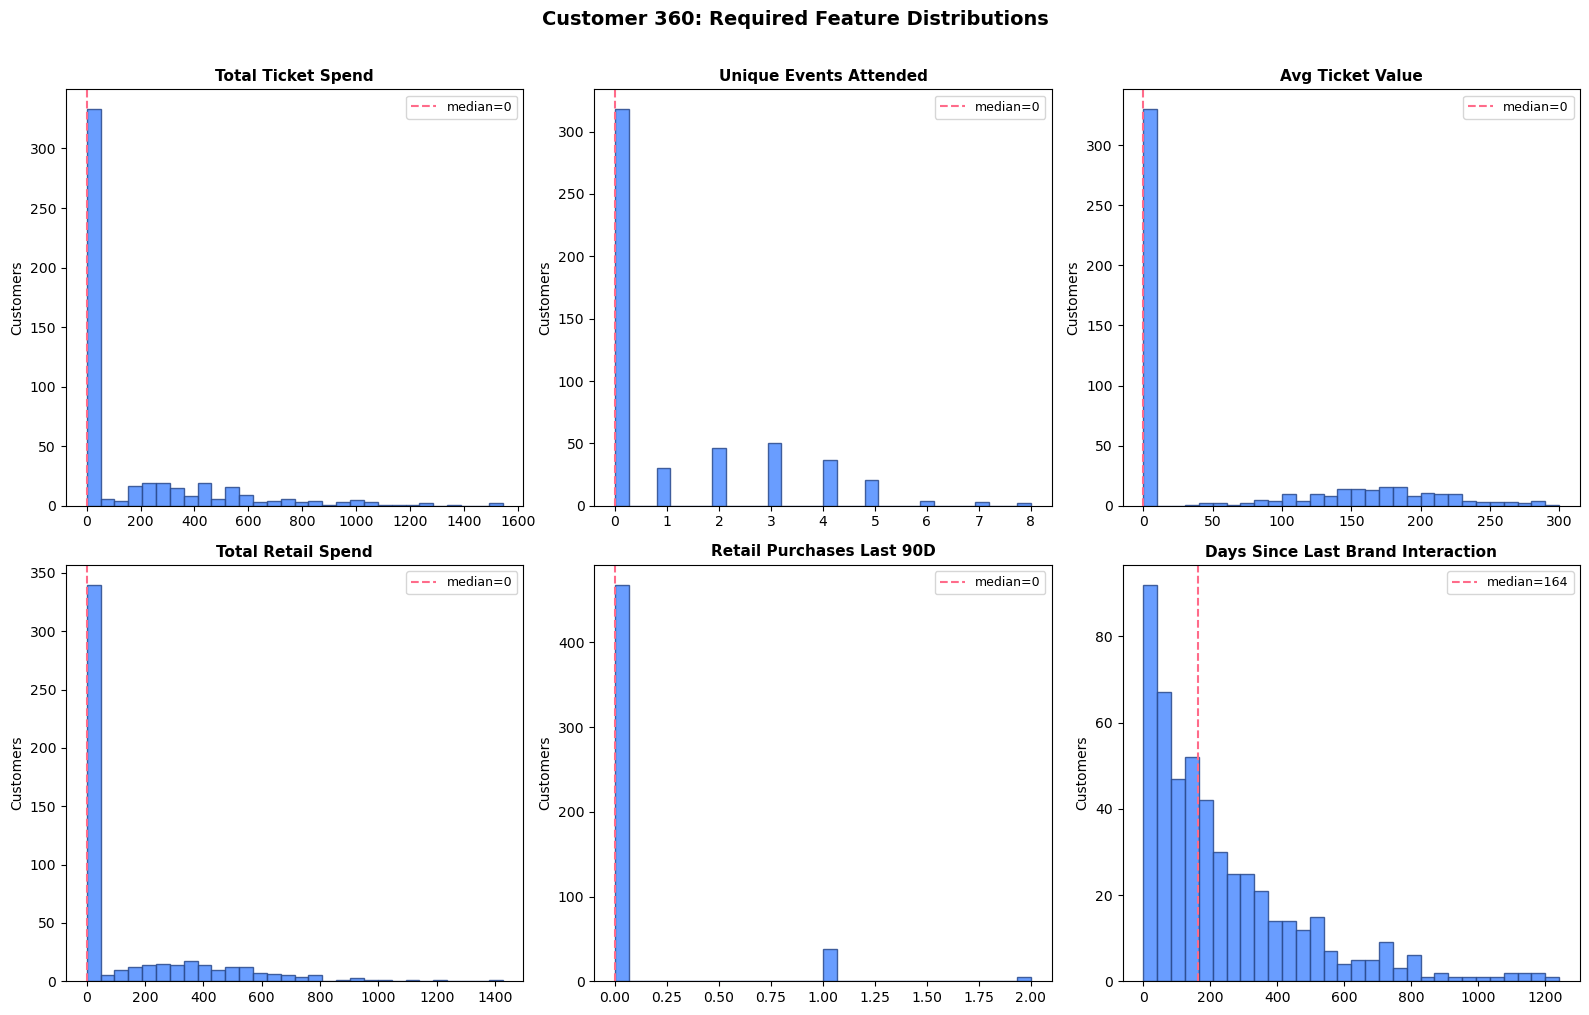

In [45]:
# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), required_features):
    data = customer_360[col].dropna()
    ax.hist(data, bins=30, color="#4f8cff", edgecolor="#2a4a8c", alpha=0.85)
    ax.set_title(col.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_ylabel("Customers")
    median_val = data.median()
    ax.axvline(median_val, color="#ff6b8a", linestyle="--", linewidth=1.5, label=f"median={median_val:.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Customer 360: Required Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("plots/c360_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# Linked vs Unlinked customer comparison
print("=== Linked vs Unlinked Customer Comparison ===\n")
comparison = (
    customer_360
    .groupby("is_linked")[required_features]
    .mean()
    .round(2)
    .T
)
comparison.columns = ["Unlinked (single-system)", "Linked (multi-system)"]
comparison

=== Linked vs Unlinked Customer Comparison ===



,Unlinked (single-system),Linked (multi-system)
total_ticket_spend,118.43,315.33
unique_events_attended,0.83,2.18
avg_ticket_value,43.16,114.80
total_retail_spend,75.53,346.33
retail_purchases_last_90d,0.05,0.23
days_since_last_brand_interaction,276.52,111.34


## Export

In [47]:
# Save the gold table
output_path = "datasets/customer_360.csv"
customer_360.to_csv(output_path, index=False)
print(f"Saved customer_360 to {output_path}")
print(f"{customer_360.shape[0]} rows × {customer_360.shape[1]} columns")

# Final schema summary ────────────────────────────────────────────────────
print(f"\n{'Column':<35s} {'Dtype':<15s} {'Non-Null':>10s} {'Null':>6s}")
print("-" * 70)
for col in customer_360.columns:
    dtype = str(customer_360[col].dtype)
    non_null = customer_360[col].notna().sum()
    null = customer_360[col].isna().sum()
    print(f"{col:<35s} {dtype:<15s} {non_null:>10,} {null:>6,}")

Saved customer_360 to datasets/customer_360.csv
511 rows × 26 columns

Column                              Dtype             Non-Null   Null
----------------------------------------------------------------------
universal_id                        object                 511      0
is_linked                           bool                   511      0
channels_active                     int64                  511      0
city                                object                 171    340
gender                              object                 171    340
age_group                           object                 171    340
profile_signup_date                 datetime64[ns]         171    340
total_ticket_spend                  float64                511      0
avg_ticket_value                    float64                511      0
ticket_purchase_count               int64                  511      0
unique_events_attended              int64                  511      0
total_retail_spend